**importing required libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

**converting the data in hand into a pandas dataset**

In [4]:
df = pd.read_csv('/content/sample_data/ola.csv')
df.head(10886)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,1/1/2011 0:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,1/1/2011 1:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,1/1/2011 2:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,1/1/2011 3:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,1/1/2011 4:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,12/19/2012 19:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,12/19/2012 20:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,12/19/2012 21:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,12/19/2012 22:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [5]:
df['weather'].unique()

array([1, 2, 3, 4])

**Fetching the overall structure of the dataset**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


**Splitting the datetime column into date and time and eventually into day, month and year columns.**

In [7]:
k1 = df["datetime"].str.split(" ",expand = True)
df["date"] = k1[0]
df["time"] = k1[1].str.split(":").str[0].astype('int')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,time
0,1/1/2011 0:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1/1/2011,0
1,1/1/2011 1:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1/1/2011,1
2,1/1/2011 2:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1/1/2011,2
3,1/1/2011 3:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1/1/2011,3
4,1/1/2011 4:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1/1/2011,4


In [8]:
k2 = df["date"].str.split("/",expand=True)
df["month"] = k2[0].astype('int')
df["day"] = k2[1].astype('int')
df["year"] = k2[2].astype('int')
df.head(10886)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,time,month,day,year
0,1/1/2011 0:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,1/1/2011,0,1,1,2011
1,1/1/2011 1:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,1/1/2011,1,1,1,2011
2,1/1/2011 2:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,1/1/2011,2,1,1,2011
3,1/1/2011 3:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,1/1/2011,3,1,1,2011
4,1/1/2011 4:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,1/1/2011,4,1,1,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,12/19/2012 19:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,12/19/2012,19,12,19,2012
10882,12/19/2012 20:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,12/19/2012,20,12,19,2012
10883,12/19/2012 21:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,12/19/2012,21,12,19,2012
10884,12/19/2012 22:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,12/19/2012,22,12,19,2012


**adding am_pm column**

In [9]:
def am_or_pm(x):
    if x > 11:
        return 1
    else:
        return 0

df['am_pm'] = df['time'].apply(am_or_pm)
df.head(24)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,time,month,day,year,am_pm
0,1/1/2011 0:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,1/1/2011,0,1,1,2011,0
1,1/1/2011 1:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,1/1/2011,1,1,1,2011,0
2,1/1/2011 2:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,1/1/2011,2,1,1,2011,0
3,1/1/2011 3:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,1/1/2011,3,1,1,2011,0
4,1/1/2011 4:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,1/1/2011,4,1,1,2011,0
5,1/1/2011 5:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1,1/1/2011,5,1,1,2011,0
6,1/1/2011 6:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2,1/1/2011,6,1,1,2011,0
7,1/1/2011 7:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3,1/1/2011,7,1,1,2011,0
8,1/1/2011 8:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8,1/1/2011,8,1,1,2011,0
9,1/1/2011 9:00,1,0,0,1,13.12,17.425,76,0.0000,8,6,14,1/1/2011,9,1,1,2011,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
 12  date        10886 non-null  object 
 13  time        10886 non-null  int64  
 14  month       10886 non-null  int64  
 15  day         10886 non-null  int64  
 16  year        10886 non-null  int64  
 17  am_pm       10886 non-null  int64  
dtypes: float64(3), int64(13), object(2)
memory usage: 1.5+ MB


**removing datetime and date column since they are redundant**

In [11]:
df.drop(["datetime", "date"],axis=1,inplace=True)

In [12]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,time,month,day,year,am_pm
0,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,1,1,2011,0
1,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,1,2011,0
2,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,1,1,2011,0
3,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,1,1,2011,0
4,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,1,1,2011,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   casual      10886 non-null  int64  
 9   registered  10886 non-null  int64  
 10  count       10886 non-null  int64  
 11  time        10886 non-null  int64  
 12  month       10886 non-null  int64  
 13  day         10886 non-null  int64  
 14  year        10886 non-null  int64  
 15  am_pm       10886 non-null  int64  
dtypes: float64(3), int64(13)
memory usage: 1.3 MB


**here, the response is the count column, and all the other columns are preditors. Now, we check for any relations between count and year, month, day & time respectively.**

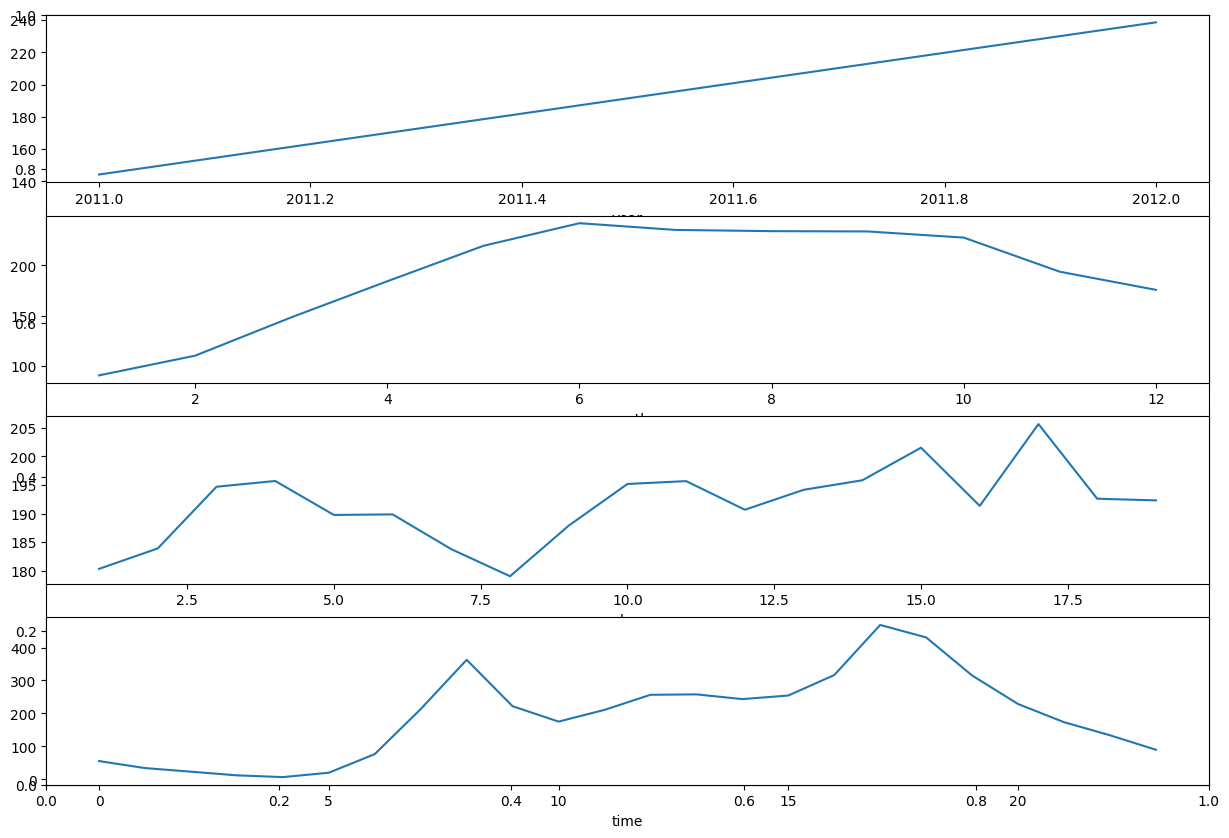

In [14]:
features = ['year', 'month','day', 'time']

plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(4, 1, i + 1)
    df.groupby(col).mean()['count'].plot()
plt.show()


**again, we check for any relationship between season, weather, holiday, workingday, am_pm**

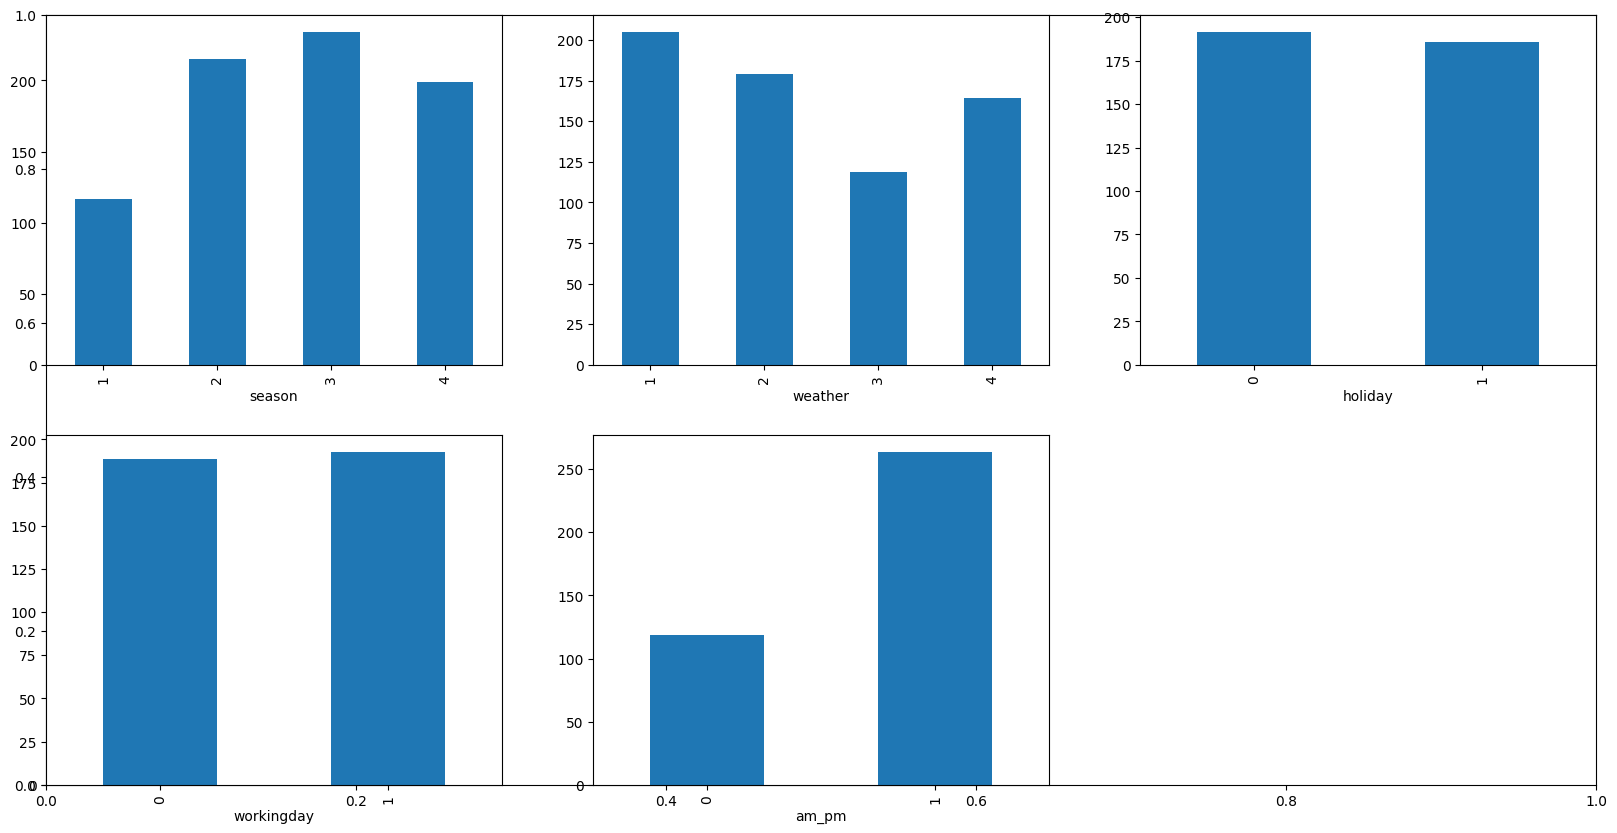

In [15]:
features = ['season', 'weather', 'holiday','workingday','am_pm']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    df.groupby(col).mean()['count'].plot.bar()
plt.show()

**again, we check for any relationship between temp, atemp, humidity, windspeed**

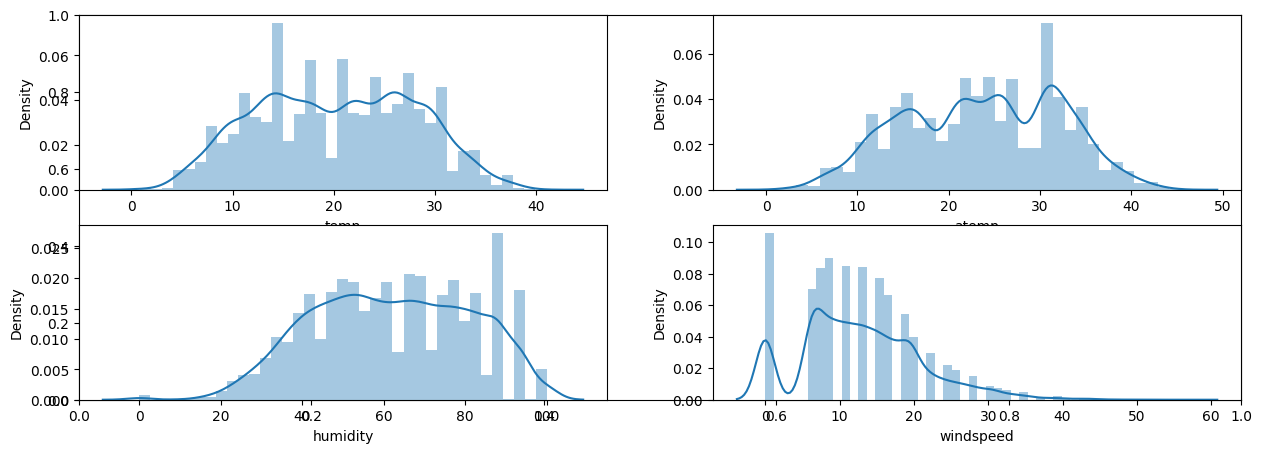

In [16]:
features = ['temp','atemp','humidity','windspeed']

plt.subplots(figsize=(15, 5))
for i, col in enumerate(features):
  plt.subplot(2, 2, i + 1)
  sb.distplot(df[col])
plt.show()

**check for outliers using boxplot**

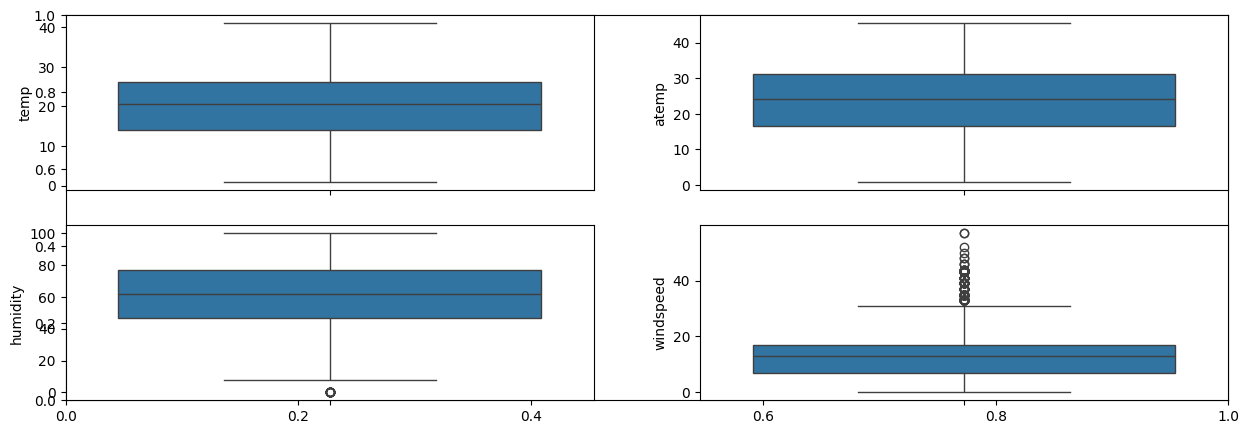

In [17]:
features = ['temp','atemp','humidity','windspeed']

plt.subplots(figsize=(15, 5))
for i, col in enumerate(features):
  plt.subplot(2, 2, i + 1)
  sb.boxplot(df[col])
plt.show()

In [19]:
c=df.shape[0]-df[(df['windspeed'] <= 30) & (df['humidity'] >= 5)].shape[0]
c

448

**since there is huge number of rows, if we remove 448 rows from that it would not generate much effect on the result.**

**ignoring outliers**

In [20]:
df=df[(df['windspeed'] <= 30) & (df['humidity'] >= 5)]
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,time,month,day,year,am_pm
0,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,1,1,2011,0
1,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,1,2011,0
2,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,1,1,2011,0
3,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,1,1,2011,0
4,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,1,1,2011,0


**check for highly correlated features**

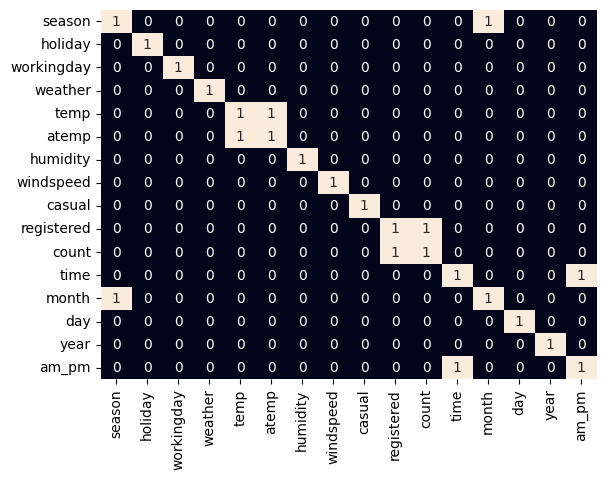

In [21]:
sb.heatmap(df.corr() > 0.8,annot=True,cbar=False)
plt.show()

**removing highly correlated features say, registered, season, workingday and time**

In [22]:
df.drop(['registered', 'season','atemp','time'], axis=1, inplace=True)
df.head()

,holiday,workingday,weather,temp,humidity,windspeed,casual,count,month,day,year,am_pm
0,0,0,1,9.84,81,0.0,3,16,1,1,2011,0
1,0,0,1,9.02,80,0.0,8,40,1,1,2011,0
2,0,0,1,9.02,80,0.0,5,32,1,1,2011,0
3,0,0,1,9.84,75,0.0,3,13,1,1,2011,0
4,0,0,1,9.84,75,0.0,0,1,1,1,2011,0


In [24]:
df.shape

(10438, 12)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10438 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   holiday     10438 non-null  int64  
 1   workingday  10438 non-null  int64  
 2   weather     10438 non-null  int64  
 3   temp        10438 non-null  float64
 4   humidity    10438 non-null  int64  
 5   windspeed   10438 non-null  float64
 6   casual      10438 non-null  int64  
 7   count       10438 non-null  int64  
 8   month       10438 non-null  int64  
 9   day         10438 non-null  int64  
 10  year        10438 non-null  int64  
 11  am_pm       10438 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 1.0 MB


**Splitting into train and test**

In [26]:
features = df.drop(['count'], axis=1)
target = df['count'].values

features_train, features_val, target_train, target_val = train_test_split(features,target,
                                                  test_size = 0.2,
                                                  random_state=22)
features_train.shape, features_val.shape


((8350, 11), (2088, 11))

**normalisation**

In [27]:
features_train = StandardScaler().fit_transform(features_train)
features_val = StandardScaler().fit_transform(features_val)

**model fitting and error generation**

In [28]:
from sklearn.metrics import root_mean_squared_error as rmse
models = [LinearRegression(), Ridge(), Lasso(),
          RandomForestRegressor()]
for i in range(4):
    models[i].fit(features_train, target_train)

    print(f'{models[i]} : ')
    train_preds = models[i].predict(features_train)
    print('Training Error : ', rmse(target_train, train_preds))

    val_preds = models[i].predict(features_val)
    print('Validation Error : ', rmse(target_val, val_preds))
    print()


LinearRegression() : 
Training Error :  115.77278192621726
Validation Error :  118.16635413885406

Ridge() : 
Training Error :  115.77278391949824
Validation Error :  118.16678507639638

Lasso() : 
Training Error :  115.8116450214334
Validation Error :  118.2016166179657

RandomForestRegressor() : 
Training Error :  35.29394684600867
Validation Error :  97.46976692034202

